# JobLens Vietnam — Phân loại nghề và dự đoán lương

Chọn mô hình theo validation; báo cáo kết quả test của các mô hình đã khai báo trước. Nhãn nghề là nhãn từ quy tắc title, không phải nhãn chuyên gia. Hồi quy dự đoán midpoint niêm yết cho năm nhóm nghề có nhãn đơn.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "configs/pipeline.json").exists() and (p / "main.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Mở notebook trong thư mục project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import read_frame
from src.pipeline import load_config, run_pipeline
CONFIG = load_config(ROOT / "configs/pipeline.json")
if not (ROOT / "data/processed/jobs_cleaned.parquet").exists():
    run_pipeline("prepare")
jobs = read_frame(ROOT / "data/processed/jobs_cleaned.parquet")
print(f"{len(jobs):,} tin; {jobs.company_group.nunique():,} nhóm công ty")


14,034 tin; 5,868 nhóm công ty


## 1. Chia dữ liệu theo công ty

Khoảng 60/20/20 số nhóm công ty. TF-IDF, imputer và vocabulary mô hình chỉ fit trên train. Không đưa title hoặc matched phrases vào đầu vào phân loại.

In [2]:
display(jobs.groupby("split").agg(rows=("id", "size"), companies=("company_group", "nunique"),
                                       classification_rows=("classification_eligible", "sum")))
display(pd.crosstab(jobs.loc[jobs.classification_eligible, "split"], jobs.loc[jobs.classification_eligible, "role_standard"]))

,rows,companies,classification_rows
split,,,
test,2565,1174,989
train,8294,3520,3139
validation,3175,1174,1224


role_standard,AI/ML Engineer,Data Analyst,Data Engineer,Data Scientist,Software Engineer
split,,,,,
test,45,103,21,21,799
train,166,335,105,51,2482
validation,48,112,49,25,990


## 2. Huấn luyện hoặc đọc kết quả

Đặt `RETRAIN=True` để huấn luyện cả ba classifier và cả ba regressor. Mặc định đọc artifacts đã tạo bằng pipeline để mở notebook nhanh.

In [3]:
RETRAIN = False
from src.pipeline import classify, salary
if RETRAIN:
    classify(jobs, CONFIG)
    salary(jobs, CONFIG)
def metrics(name):
    path = ROOT / "reports" / name
    if not path.exists():
        raise FileNotFoundError(f"Thiếu {path.name}; chạy main.py --stage all hoặc bật RETRAIN")
    return json.loads(path.read_text(encoding="utf-8"))
classification = metrics("classification_metrics.json")
regression = metrics("salary_metrics.json")

## 3. TF-IDF + Logistic Regression / LinearSVC / MLP

Macro-F1 cho trọng số đều giữa các lớp, phù hợp khi SoftwareEngineer chiếm phần lớn. Baseline dự đoán lớp phổ biến trên train. Precision/recall mỗi lớp cho biết sai lệch với các nhóm nhỏ.

,model,validation_macro_f1,test_macro_f1,test_precision_macro,test_recall_macro
0,tfidf_logistic,0.742012,0.843948,0.919352,0.817745
1,tfidf_svm,0.750958,0.839098,0.936408,0.793447
2,tfidf_mlp,0.677674,0.749171,0.908715,0.679264


Selected: tfidf_svm | baseline F1: 0.17874720357941834


,precision,recall,f1-score,support
AI/ML Engineer,0.800000,0.888889,0.842105,45.000000
Data Analyst,0.898148,0.941748,0.919431,103.000000
Data Engineer,1.000000,0.666667,0.800000,21.000000
Data Scientist,1.000000,0.476190,0.645161,21.000000
Software Engineer,0.983891,0.993742,0.988792,799.000000
accuracy,0.965622,0.965622,0.965622,0.965622
macro avg,0.936408,0.793447,0.839098,989.000000
weighted avg,0.967278,0.965622,0.963589,989.000000


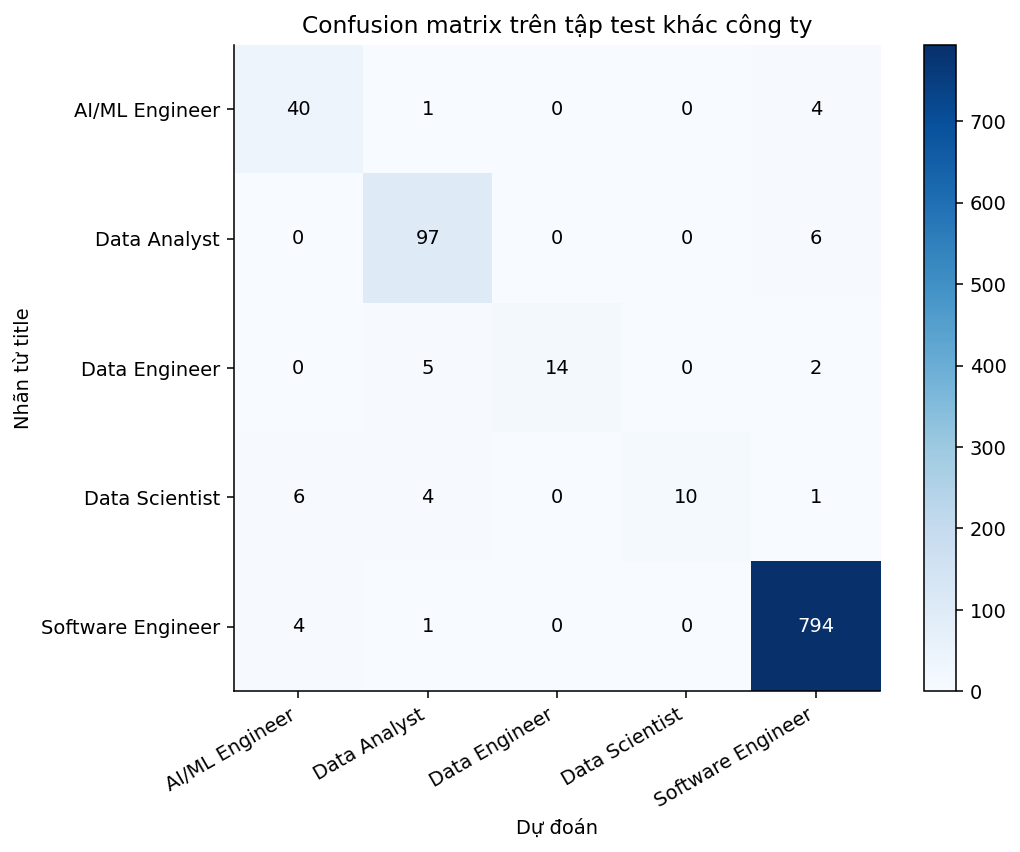

In [4]:
comparison = pd.DataFrame([{ "model": name, "validation_macro_f1": result["validation"]["macro_f1"],
                            "test_macro_f1": result["test"]["macro_f1"],
                            "test_precision_macro": result["test"]["precision_macro"],
                            "test_recall_macro": result["test"]["recall_macro"] }
                          for name, result in classification["models"].items()])
display(comparison)
print("Selected:", classification["selected_model"], "| baseline F1:", classification["baseline_macro_f1"])
selected_metrics = classification["models"][classification["selected_model"]]["test"]
display(pd.DataFrame(selected_metrics["classification_report"]).T)
display(Image(filename=str(ROOT / "reports/figures/classification_confusion.png")))

## 4. LightGBM / Random Forest / Ridge

Target `log1p(salary_mean)`. Ngưỡng 1–99% học trên train và chỉ cắt train; validation/test giữ toàn bộ midpoint hợp lệ. Baseline dùng trung vị train. MAE và RMSE được tính sau chuyển về VND/tháng.

,model,validation_mae_million,test_mae_million,test_rmse_million,test_r2
0,lightgbm,7.413559,6.119001,9.526083,0.386627
1,random_forest,7.573640,6.276459,9.877072,0.340595
2,ridge,7.799381,6.373577,9.901993,0.337264


Selected: lightgbm | baseline MAE triệu: 8.190633423180593
Train salary bounds: [2000000.0, 65000000.0] | rows removed: 44


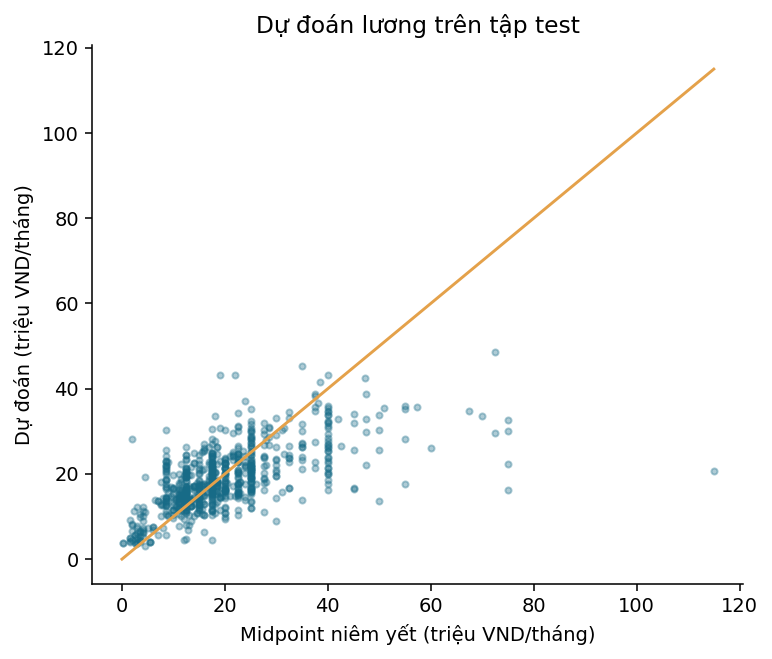

In [5]:
display(pd.DataFrame([{ "model": name, "validation_mae_million": result["validation"]["mae_vnd"] / 1e6,
                            "test_mae_million": result["test"]["mae_vnd"] / 1e6,
                            "test_rmse_million": result["test"]["rmse_vnd"] / 1e6,
                            "test_r2": result["test"]["r2"] }
                          for name, result in regression["models"].items()]))
print("Selected:", regression["selected_model"], "| baseline MAE triệu:", regression["baseline_mae_vnd"] / 1e6)
print("Train salary bounds:", regression["training_bounds_vnd"], "| rows removed:", regression["training_rows_removed"])
display(Image(filename=str(ROOT / "reports/figures/salary_predictions.png")))

## 5. Tree SHAP

Giải thích mô hình cây tốt nhất theo validation, có thể khác mô hình lương được chọn nếu Ridge thắng. SHAP ở thang log1p, không phải mức tăng lương nhân quả của một kỹ năng.

SHAP model: lightgbm


,feature,mean_abs_shap_log,mean_shap_log
0,categorical__seniority_Junior,0.166629,-0.038331
1,numeric__experience_min,0.106513,0.022539
2,numeric__skill_count,0.070812,0.010110
3,categorical__seniority_Unspecified,0.065272,0.017061
4,categorical__job_position_Nhân viên,0.044785,0.006260
5,numeric__missingindicator_experience_min,0.039560,-0.001162
6,categorical__location_group_Hà Nội,0.038084,0.001593
7,numeric__year,0.035455,-0.004642
8,categorical__education_level_Đại học,0.028081,0.001488
9,categorical__job_position_Cộng tác viên,0.026119,-0.000945


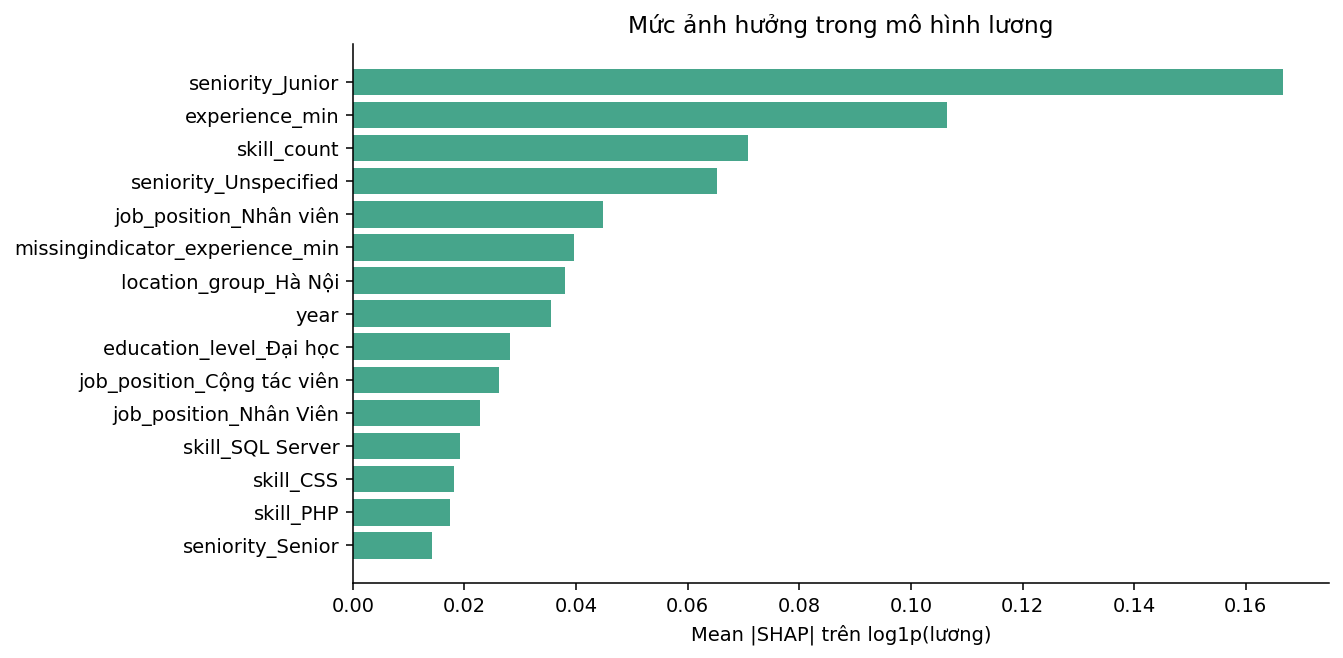

In [6]:
print("SHAP model:", regression["shap_model"])
display(pd.read_csv(ROOT / "reports/salary_shap_importance.csv").head(20))
display(Image(filename=str(ROOT / "reports/figures/salary_shap.png")))

## 6. Dùng mô hình đã lưu

Chỉ áp dụng classifier cho bài toán năm nhóm. Giá trị dự đoán không có lớp Other; việc một JD nằm ngoài phạm vi phải được xét riêng.

In [7]:
import joblib
from src.models.regressor import INPUT_FEATURES
role_model = joblib.load(ROOT / "artifacts/models/role_classifier.joblib")
salary_model = joblib.load(ROOT / "artifacts/models/salary_regressor.joblib")
examples = jobs.loc[jobs.split.eq("test") & jobs.classification_eligible & jobs.salary_eligible].head(8)
predictions = examples[["title_clean", "role_standard", "salary_mean"]].copy()
predictions["predicted_role"] = role_model.predict(examples.text_clean)
predictions["predicted_salary_vnd"] = salary_model.predict(examples[INPUT_FEATURES])
display(predictions)

,title_clean,role_standard,salary_mean,predicted_role,predicted_salary_vnd
9,"Middle Frontend (Thu Nhập 18-25tr/Tháng, Nguyễ...",Software Engineer,21500000.0,Software Engineer,2.426663e+07
17,[HN] Công Ty Giải Pháp Công Nghệ Migi Technolo...,Software Engineer,12500000.0,Software Engineer,2.433947e+07
62,AI Engineer,AI/ML Engineer,22500000.0,AI/ML Engineer,3.010284e+07
144,Lập Trình Viên iOS,Software Engineer,15000000.0,Software Engineer,2.320174e+07
158,Kỹ Sư Lập Trình Frontend,Software Engineer,17500000.0,Software Engineer,2.016630e+07
188,Kỹ Sư Lập Trình Backend,Software Engineer,17500000.0,Software Engineer,1.864705e+07
199,Lập Trình Viên Backend Middle Node.Js (Thu Nhậ...,Software Engineer,21500000.0,Software Engineer,2.954601e+07
210,[HN] Công Ty Công Nghệ MOBIWORK Tuyển Dụng Lập...,Software Engineer,12500000.0,Software Engineer,1.930588e+07


## 7. Giới hạn đánh giá

Cần bổ sung nhãn thủ công, chuẩn hóa alias công ty và holdout theo năm. Mẫu gán nhãn trong `reports/annotation_template.csv`. Dữ liệu thiếu lương/nhãn đơn bị loại khỏi mô hình và có thể tạo sai lệch chọn mẫu.